# 01 - Webcam AI Classifier Training

Notebook ini membuat pipeline klasifikasi emergency vehicle menggunakan dataset `Dataset/webcam`.
Fokus: deteksi `ambulance` / `pemadam_kebakaran` vs `non_emergency`, lalu menampilkan analisis dan simulasi lampu lalu lintas.

In [ ]:
import json
from pathlib import Path
from PIL import Image, ImageEnhance
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import random

try:
    import cv2
    HAS_CV2 = True
except ImportError:
    HAS_CV2 = False

sns.set(style='whitegrid', rc={'figure.figsize': (9, 6)})
DATA_ROOT = Path('../Dataset/baru').resolve()
MODEL_DIR = Path('../Trained_Model').resolve()
MODEL_DIR.mkdir(parents=True, exist_ok=True)

## 1. Ringkasan Dataset
Kita cek jumlah gambar per kelas untuk memastikan apakah dataset sudah layak digunakan.

In [ ]:
rows = []
for split in ['train', 'val']:
    folder = DATA_ROOT / split
    if not folder.exists():
        continue
    for class_dir in sorted(folder.iterdir()):
        if not class_dir.is_dir():
            continue
        count = len(list(class_dir.glob('*')))
        rows.append({'split': split, 'class': class_dir.name, 'count': count})
df_counts = pd.DataFrame(rows)
display(df_counts)

if df_counts.empty:
    print('Dataset tidak ditemukan di', DATA_ROOT)
else:
    total = df_counts['count'].sum()
    print(f'Total gambar terdaftar: {total}')

,split,class,count
0,train,ambulance,62
1,train,non_emergency,52
2,train,pemadam_kebakaran,48
3,val,ambulance,10
4,val,non_emergency,10
5,val,pemadam_kebakaran,10


Total gambar terdaftar: 192


### Catatan dataset
- Kelas `ambulance` dan `pemadam_kebakaran` akan dianggap sebagai emergency.
- `non_emergency` adalah kelas negatif.
- Jika folder `val` kosong, kita akan membuat validasi internal dari `train`.

## 2. Fungsi ekstraksi fitur
Kita gunakan ekstraksi fitur sederhana agar dapat dijalankan dengan cepat di notebook.

In [ ]:
def extract_features(image, size=(128, 128)):
    image = image.convert('RGB').resize(size)
    arr = np.array(image)
    if HAS_CV2:
        histograms = [cv2.calcHist([arr], [i], None, [32], [0, 256]).flatten() for i in range(3)]
        hist = np.concatenate(histograms)
        gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        edge_stats = np.array([edges.mean(), edges.std(), edges.max()])
    else:
        histograms = [np.histogram(arr[:, :, i], bins=32, range=(0, 255))[0].astype(float) for i in range(3)]
        hist = np.concatenate(histograms)
        gray = np.mean(arr, axis=2).astype(np.uint8)
        edge_stats = np.array([gray.mean(), gray.std(), gray.max()])
    return np.concatenate([hist, edge_stats])


def augment_image(image):
    image = image.convert('RGB')
    angle = random.uniform(-12, 12)
    image = image.rotate(angle, resample=Image.BILINEAR, expand=False)
    image = image.resize((128, 128), Image.BILINEAR)
    enhancer = ImageEnhance.Brightness(image)
    image = enhancer.enhance(random.uniform(0.85, 1.15))
    enhancer = ImageEnhance.Contrast(image)
    image = enhancer.enhance(random.uniform(0.85, 1.15))
    return image


def load_images_from_folder(folder, label, augment=False):
    features = []
    labels = []
    for image_path in sorted(folder.glob('*')):
        try:
            image = Image.open(image_path)
            features.append(extract_features(image))
            labels.append(label)
            if augment:
                augmented = augment_image(image)
                features.append(extract_features(augmented))
                labels.append(label)
        except Exception as err:
            print('Gagal memproses', image_path, err)
    return features, labels

def map_label(class_name):
    if class_name in ['ambulance', 'pemadam_kebakaran']:
        return 'emergency'
    return 'non_emergency'

## 3. Persiapan data pelatihan
Jika folder `val` tidak berisi data, kita akan membuat split internal dari data `train`.

In [ ]:
X = []
y = []

# Load train + validation jika tersedia
for split in ['train', 'val']:
    split_folder = DATA_ROOT / split
    if not split_folder.exists():
        continue
    for class_dir in sorted(split_folder.iterdir()):
        if not class_dir.is_dir():
            continue
        label = map_label(class_dir.name)
        augment = split == 'train'
        features, labels = load_images_from_folder(class_dir, label, augment=augment)
        X.extend(features)
        y.extend(labels)

X = np.array(X)
y = np.array(y)
print('Bentuk fitur:', X.shape)
print('Bentuk label:', y.shape)
print('Distribusi kelas:', pd.Series(y).value_counts().to_dict())

Bentuk fitur: (354, 99)
Bentuk label: (354,)
Distribusi kelas: {'emergency': 240, 'non_emergency': 114}


## 4. Training model
Kita gunakan model Random Forest untuk hasil yang cepat dan mudah dioptimasi.

Accuracy on validation set: 0.8028169014084507
Classification report:
               precision    recall  f1-score   support

    emergency       0.79      0.96      0.87        48
non_emergency       0.85      0.48      0.61        23

     accuracy                           0.80        71
    macro avg       0.82      0.72      0.74        71
 weighted avg       0.81      0.80      0.78        71



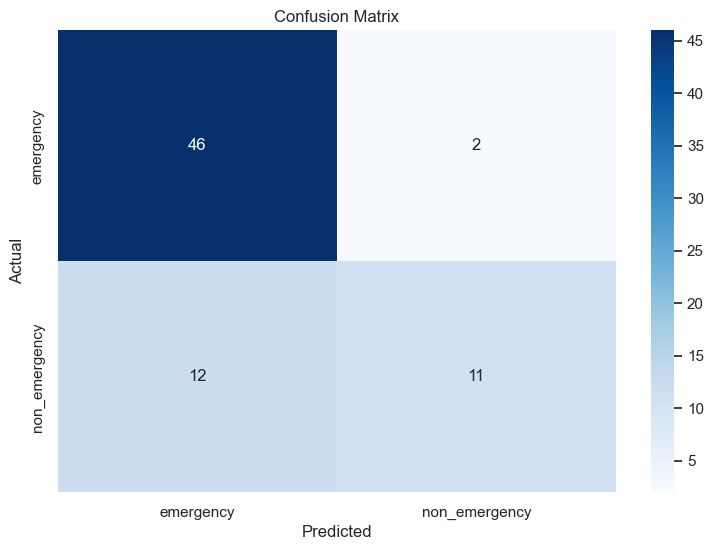

Model tersimpan di C:\Adella\coding\projek ai\Smart-Emergency-Traffic-System\Trained_Model\webcam_classifier.pkl
Label mapping tersimpan di C:\Adella\coding\projek ai\Smart-Emergency-Traffic-System\Trained_Model\webcam_classes.json


In [ ]:
if len(X) == 0:
    raise RuntimeError('Tidak ada data pelatihan. Periksa kembali letak dataset di Dataset/webcam.')

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

clf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_val)
print('Accuracy on validation set:', accuracy_score(y_val, y_pred))
print('Classification report:')
print(classification_report(y_val, y_pred, target_names=encoder.classes_))

cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=encoder.classes_, yticklabels=encoder.classes_, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

model_path = MODEL_DIR / 'webcam_classifier.pkl'
joblib.dump(clf, model_path)
print('Model tersimpan di', model_path)

classes_path = MODEL_DIR / 'webcam_classes.json'
classes_data = {'classes': encoder.classes_.tolist()}
classes_path.write_text(json.dumps(classes_data, indent=2, ensure_ascii=False))
print('Label mapping tersimpan di', classes_path)

## 5. Demo prediksi dan simulasi lampu lalu lintas
Kita tunjukkan hasil prediksi pada gambar contoh, lengkap dengan analisis dan visualisasi lampu merah/hijau.

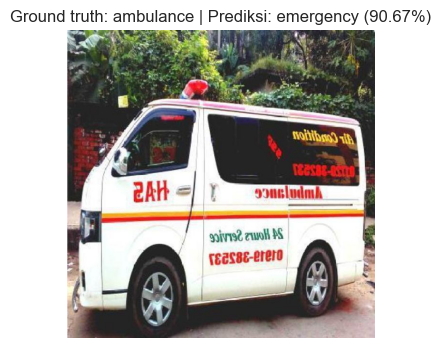

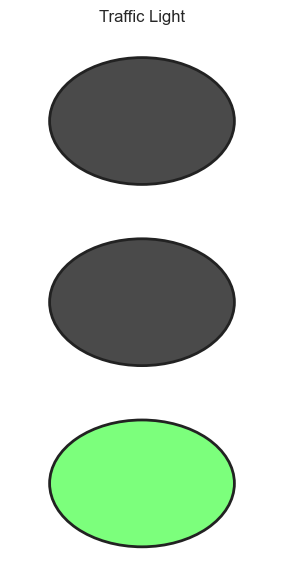

Analisis:
  - Source: train/ambulance
  - Prediksi: emergency (90.67%)
  - Emergency vehicle terdeteksi. Lampu akan hijau untuk membuka koridor.



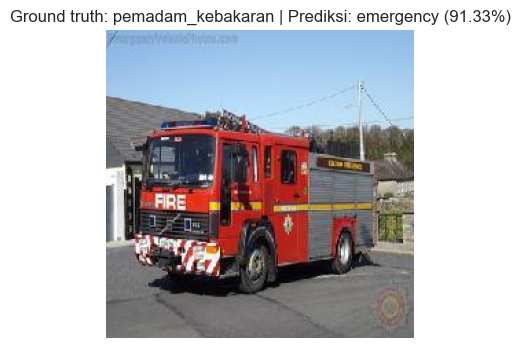

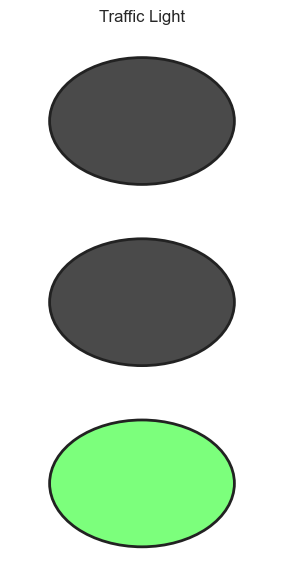

Analisis:
  - Source: train/pemadam_kebakaran
  - Prediksi: emergency (91.33%)
  - Emergency vehicle terdeteksi. Lampu akan hijau untuk membuka koridor.



c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\USER

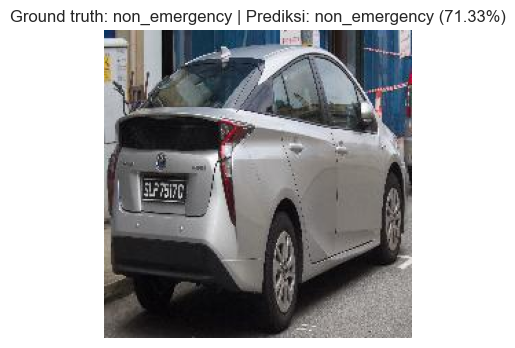

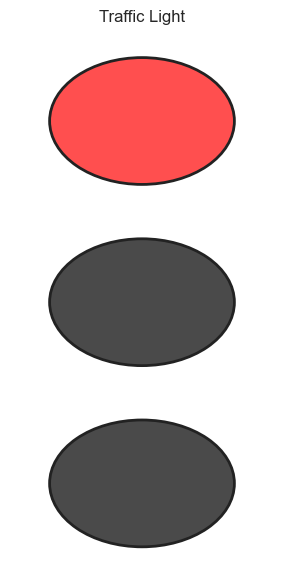

Analisis:
  - Source: train/non_emergency
  - Prediksi: non_emergency (71.33%)
  - Kendaraan biasa terdeteksi. Lampu tetap merah.



c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\USER

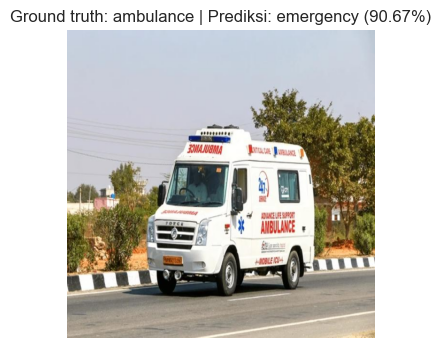

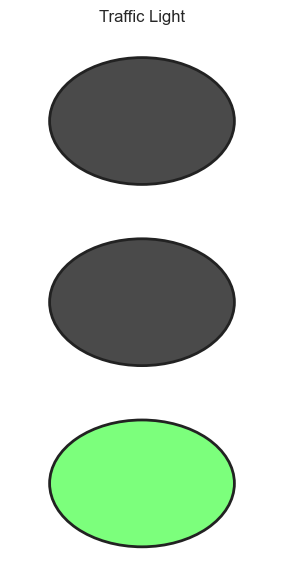

Analisis:
  - Source: val/ambulance
  - Prediksi: emergency (90.67%)
  - Emergency vehicle terdeteksi. Lampu akan hijau untuk membuka koridor.



c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\USER

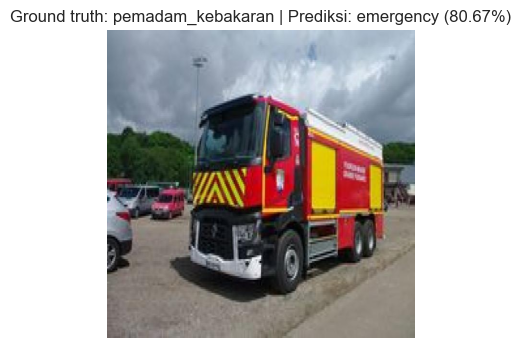

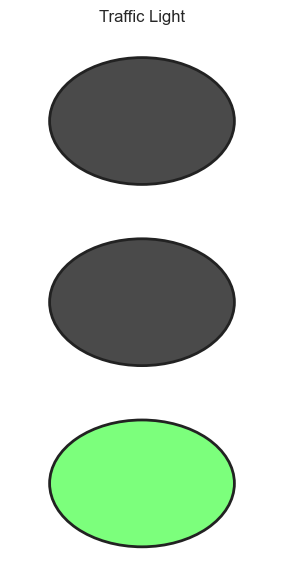

Analisis:
  - Source: val/pemadam_kebakaran
  - Prediksi: emergency (80.67%)
  - Emergency vehicle terdeteksi. Lampu akan hijau untuk membuka koridor.



c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\USER

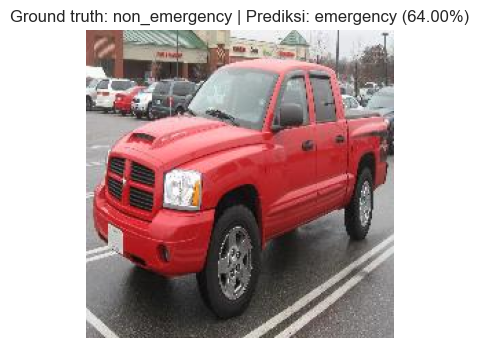

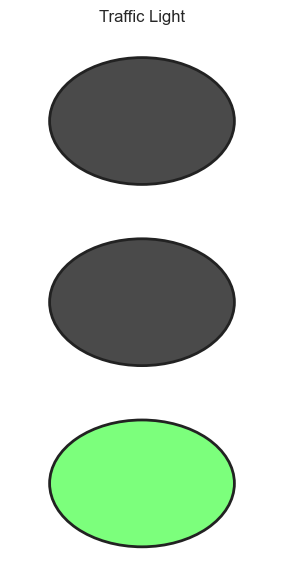

Analisis:
  - Source: val/non_emergency
  - Prediksi: emergency (64.00%)
  - Emergency vehicle terdeteksi. Lampu akan hijau untuk membuka koridor.



In [ ]:
def render_traffic_light(is_emergency):
    colors = ['#ff4f4f', '#4a4a4a', '#4a4a4a'] if not is_emergency else ['#4a4a4a', '#4a4a4a', '#7cff7c']
    fig, ax = plt.subplots(figsize=(3, 6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 3)
    ax.axis('off')
    for idx, color in enumerate(colors):
        circle = plt.Circle((0.5, 2.5 - idx), 0.35, color=color, ec='#222', lw=2)
        ax.add_patch(circle)
    ax.set_title('Traffic Light')
    plt.tight_layout()
    plt.show()

def predict_image(image_path):
    image = Image.open(image_path)
    features = extract_features(image)
    pred_idx = clf.predict([features])[0]
    proba = clf.predict_proba([features])[0].max()
    pred_label = encoder.inverse_transform([pred_idx])[0]
    return image, pred_label, proba


def collect_demo_samples(root, target_classes, n=1):
    samples = []
    for split in ['train', 'val']:
        for class_name in target_classes:
            folder = root / split / class_name
            if not folder.exists():
                continue
            files = sorted(folder.glob('*'))[:n]
            for fp in files:
                samples.append((fp, class_name, split))
    return samples

sample_items = collect_demo_samples(DATA_ROOT, ['ambulance', 'pemadam_kebakaran', 'non_emergency'], n=1)
if not sample_items:
    raise RuntimeError('Tidak ditemukan contoh gambar demo di Dataset/webcam/train atau Dataset/webcam/val.')

for sample_path, true_class, split in sample_items:
    image, pred_label, proba = predict_image(sample_path)
    plt.figure(figsize=(5, 4))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'Ground truth: {true_class} | Prediksi: {pred_label} ({proba:.2%})')
    plt.show()

    is_emergency = pred_label == 'emergency'
    render_traffic_light(is_emergency)

    print('Analisis:')
    print(f'  - Source: {split}/{true_class}')
    print(f'  - Prediksi: {pred_label} ({proba:.2%})')
    if is_emergency:
        print('  - Emergency vehicle terdeteksi. Lampu akan hijau untuk membuka koridor.')
    else:
        print('  - Kendaraan biasa terdeteksi. Lampu tetap merah.')
    print('')

## 6. Capture webcam frame (opsional)
Jika Anda menjalankan notebook pada mesin dengan webcam, aktifkan cell ini untuk memberi model satu frame langsung dari kamera.
Jika `opencv-python` belum terpasang, install terlebih dahulu dan jalankan ulang notebook.

In [ ]:
if not HAS_CV2:
    raise ImportError('opencv-python belum tersedia. Install dengan `pip install opencv-python` dan jalankan ulang notebook.')

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError('Tidak dapat mengakses webcam. Pastikan webcam terhubung dan tidak digunakan aplikasi lain.')
ret, frame = cap.read()
cap.release()
if not ret:
    raise RuntimeError('Gagal menangkap frame dari webcam.')

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
frame_image = Image.fromarray(frame_rgb)
plt.figure(figsize=(6, 4))
plt.imshow(frame_image)
plt.axis('off')
plt.title('Frame Webcam yang Ditangkap')
plt.show()

features = extract_features(frame_image)
pred_idx = clf.predict([features])[0]
pred_label = encoder.inverse_transform([pred_idx])[0]
confidence = clf.predict_proba([features])[0].max()
print(f'Prediksi webcam: {pred_label} ({confidence:.2%})')
render_traffic_light(pred_label == 'emergency')